# Machine Learning: Crop Classification - KCropAI
**Dataset:** `crop_recommendation.csv`

### Objective
To build a classification model that recommends the most suitable crop to plant based on precise soil metrics (Nitrogen, Phosphorous, Potassium, pH) and environmental conditions (Temperature, Humidity, Rainfall).

We will use a **Random Forest Classifier** because it handles non-linear agricultural data exceptionally well and is highly resistant to overfitting.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

# Set visualization style
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

print("Import Success")

Import Success


In [2]:
# 1. Load the dataset
df = pd.read_csv('../data/crop_recommendation.csv')
print(f"Dataset Loaded: {df.shape[0]} rows and {df.shape[1]} columns.")

# 2. Separate Features (X) and Target (y)
features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
X = df[features]
y = df['label']

# 3. Encode the Target Variable (Crop Names -> Numbers)
# This is crucial for the model to process the labels mathematically
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("\nFeatures (X):", features)
print(f"Target (y): 'label' ({len(label_encoder.classes_)} unique crops)")

Dataset Loaded: 2200 rows and 8 columns.

Features (X): ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
Target (y): 'label' (22 unique crops)


### Model Training & Evaluation
We split our dataset into a training set (80%) to teach the model, and a testing set (20%) to evaluate its performance on unseen data.

In [3]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# Initialize and train the Random Forest Classifier
print("Training the Random Forest model")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
print("Model Training Complete")

# Make predictions on the test set
y_pred = rf_model.predict(X_test)

# Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy on Test Data: {accuracy * 100:.2f}%")

Training the Random Forest model
Model Training Complete

Model Accuracy on Test Data: 99.32%


Detailed Classification Report
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        23
      banana       1.00      1.00      1.00        21
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        26
     coconut       1.00      1.00      1.00        27
      coffee       1.00      1.00      1.00        17
      cotton       1.00      1.00      1.00        17
      grapes       1.00      1.00      1.00        14
        jute       0.92      1.00      0.96        23
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.92      1.00      0.96        11
       maize       1.00      1.00      1.00        21
       mango       1.00      1.00      1.00        19
   mothbeans       1.00      0.96      0.98        24
    mungbean       1.00      1.00      1.00        19
   muskmelon       1.00      1.00      1.00        17
      orange       1.00      1.00      1.00       

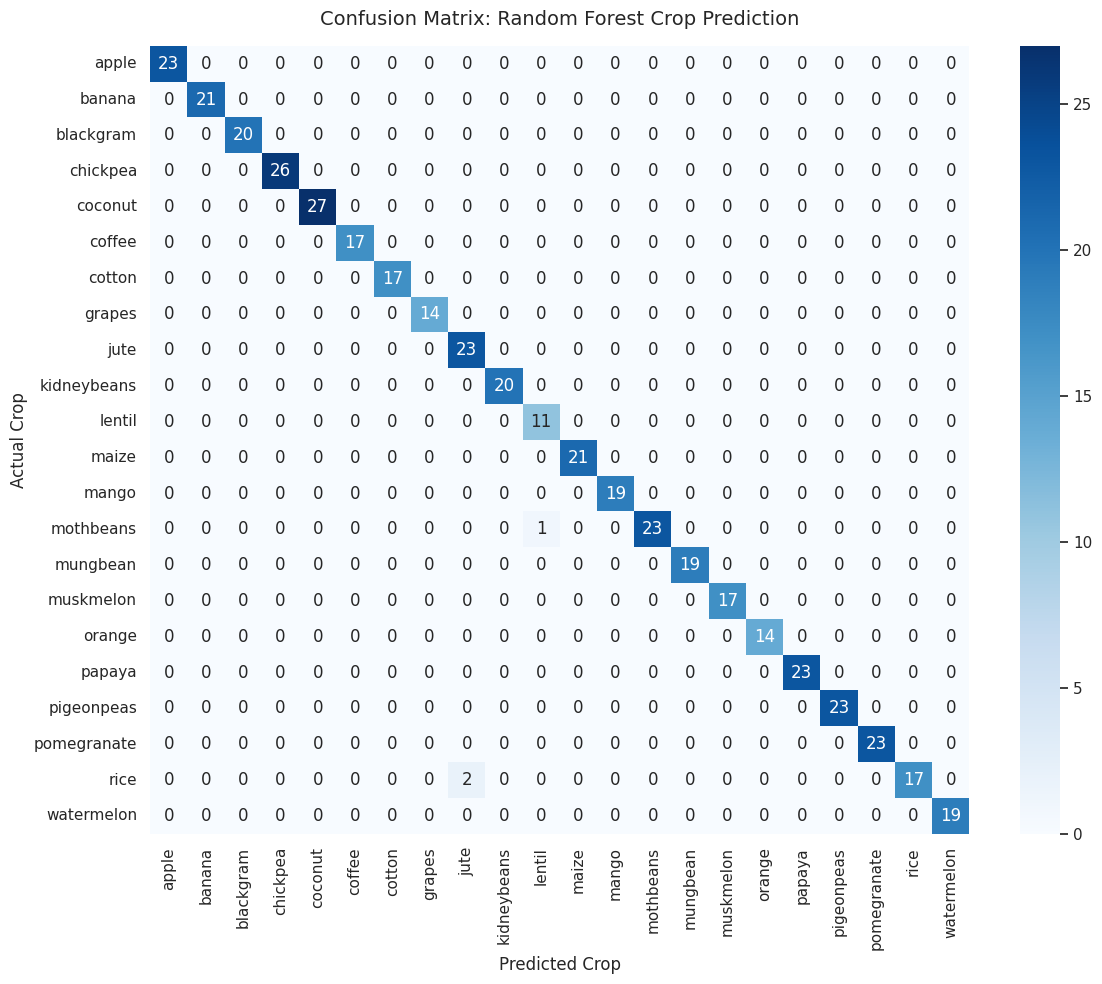

In [4]:
# Generate a detailed classification report
print("Detailed Classification Report")
# We use inverse_transform to show the actual crop names instead of numbers
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# Generate and plot the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder.classes_, 
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix: Random Forest Crop Prediction', fontsize=14, pad=15)
plt.xlabel('Predicted Crop', fontsize=12)
plt.ylabel('Actual Crop', fontsize=12)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Saving the Model for Deployment
To use this trained logic in our Streamlit web application (`app.py`), we must export the trained model and the label encoder as `.pkl` files to the `src/` directory.

In [5]:
import os

# Ensure the src/ directory exists
os.makedirs('../src', exist_ok=True)

# Save the Random Forest model
model_path = '../src/rf_model.pkl'
joblib.dump(rf_model, model_path)

# Save the Label Encoder (so the app can translate the number back to a crop name)
encoder_path = '../src/label_encoder.pkl'
joblib.dump(label_encoder, encoder_path)

print(f"Model successfully saved to: {model_path}")
print(f"Label Encoder successfully saved to: {encoder_path}")
print("The Machine Learning pipeline is now ready for UI integration!")

Model successfully saved to: ../src/rf_model.pkl
Label Encoder successfully saved to: ../src/label_encoder.pkl
The Machine Learning pipeline is now ready for UI integration!
